# DermaCheck - Combined Preprocessing Pipeline
**Group ID:** 2026-Y2S1-MLB-B3G2-03

**Module:** IT2011 — Artificial Intelligence and Machine Learning

This notebook chains every member's finished preprocessing step into a single,
reproducible run: raw CSV → missing values → encoding → outlier removal →
scaling → feature engineering → feature selection → final processed dataset.

| Step | Technique | Owner |
|---|---|---|
| 1 | Load & inspect data | — |
| 2 | Missing value imputation | IT25101908 |
| 3 | Categorical encoding | IT25102853 |
| 4 | Outlier removal | IT25103722 |
| 5 | Feature scaling | IT25101857 |
| 6 | Feature engineering (assembly) | IT25103708 |
| 7 | Feature selection / dimensionality reduction | IT25100928 |


## Imports & Setup main Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## Step 1 — Load & Inspect Data
This is the **only** cell in the whole notebook that reads the raw CSV. Everything after this operates on `df` as it evolves through each step.

In [3]:
df = pd.read_csv("data/raw/HAM10000_metadata.csv")

print("Shape:", df.shape)
df.info()
df.head()

Shape: (10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Step 2 — Missing Value Handling
**Owner:** IT25101908
**Technique:** Median imputation for `age`

Median is used instead of mean because age can be slightly skewed, and median
is more robust to that skew/outliers.

In [4]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

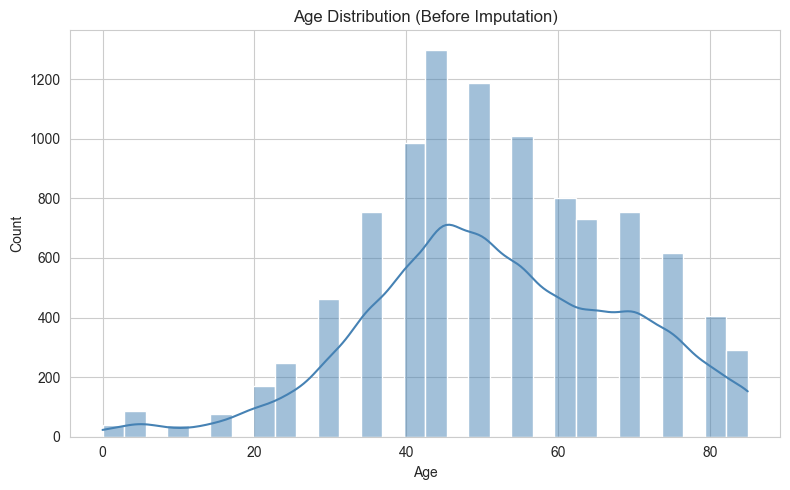

In [5]:
# EDA: age distribution BEFORE imputation
plt.figure(figsize=(8,5))
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Age Distribution (Before Imputation)')
plt.xlabel('Age'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('results/eda_visualizations/age_distribution_before.png', dpi=150)
plt.show()

In [6]:
median_age = df['age'].median()
print("Median age used for imputation:", median_age)

df['age'] = df['age'].fillna(median_age)

print("Remaining missing age values:", df['age'].isnull().sum())

Median age used for imputation: 50.0
Remaining missing age values: 0


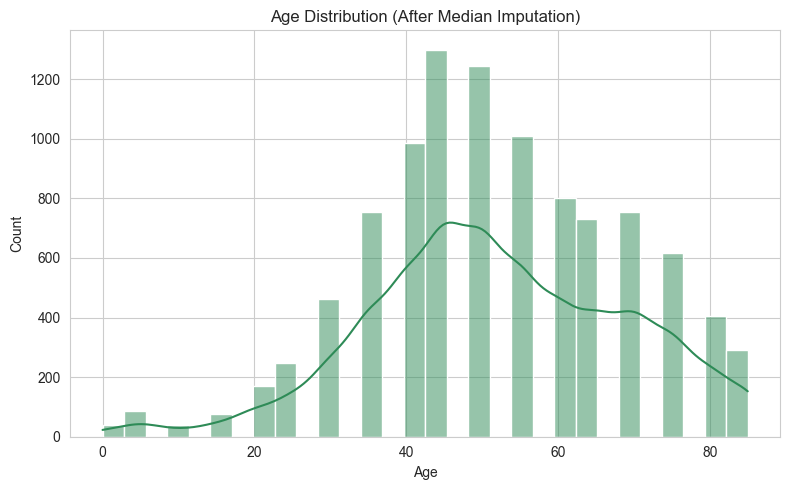

In [7]:
# EDA: age distribution AFTER imputation
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color='seagreen')
plt.title('Age Distribution (After Median Imputation)')
plt.xlabel('Age'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('results/eda_visualizations/age_distribution_after.png', dpi=150)
plt.show()

**Interpretation:** The overall shape of the age distribution is preserved
after imputation — the median fill doesn't distort the tails, confirming this
step didn't introduce bias into `age` before it feeds into scaling and outlier
handling.

## Step 3 — Categorical Encoding
**Owner:** IT25102853
**Technique:** One-hot encoding of `sex` and `localization`

Both are nominal categorical variables — no inherent order — so one-hot encoding
is used instead of label encoding, which would falsely imply a ranking between
categories.

In [8]:
df['sex'].value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

In [9]:
df['localization'].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

In [10]:
# One-hot encode sex and localization
df = pd.get_dummies(df, columns=['sex', 'localization'], prefix=['sex', 'loc'])

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (10015, 23)


,lesion_id,image_id,dx,dx_type,age,sex_female,sex_male,sex_unknown,loc_abdomen,loc_acral,loc_back,loc_chest,loc_ear,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [11]:
# Sanity check: exactly one active category per row for each encoded feature
sex_cols = [c for c in df.columns if c.startswith('sex_')]
loc_cols = [c for c in df.columns if c.startswith('loc_')]

print("Sex one-hot check (should be [1]):", df[sex_cols].sum(axis=1).unique())
print("Localization one-hot check (should be [1]):", df[loc_cols].sum(axis=1).unique())

Sex one-hot check (should be [1]): [1]
Localization one-hot check (should be [1]): [1]


C:\Program Files\KMSpico\temp\ipykernel_10968\1302688409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_counts.values, y=[c.replace('loc_', '') for c in loc_counts.index], palette='viridis')


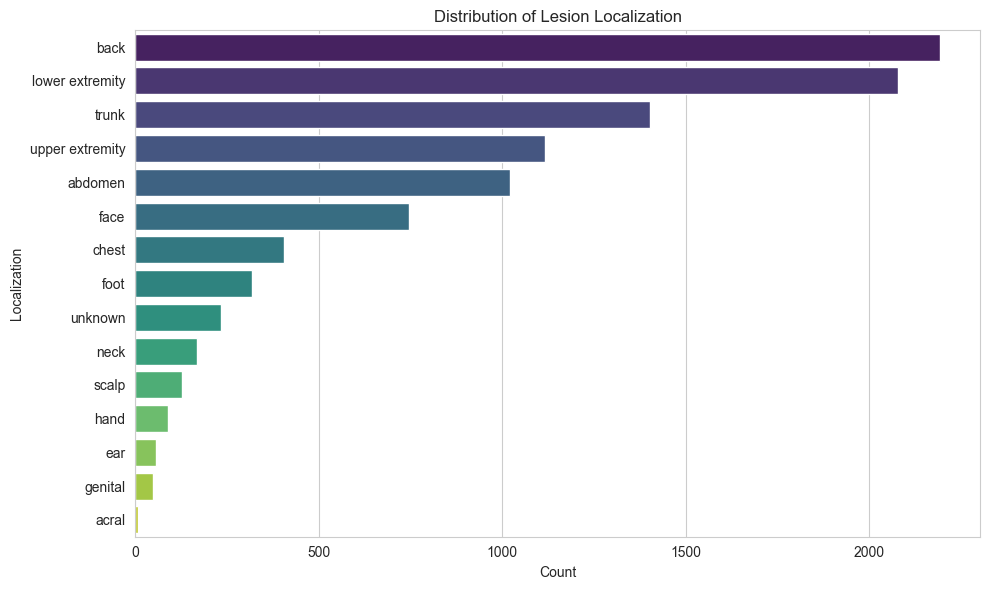

In [12]:
# EDA: class distribution of localization
plt.figure(figsize=(10,6))
loc_counts = df[loc_cols].sum().sort_values(ascending=False)
sns.barplot(x=loc_counts.values, y=[c.replace('loc_', '') for c in loc_counts.index], palette='viridis')
plt.title('Distribution of Lesion Localization')
plt.xlabel('Count'); plt.ylabel('Localization')
plt.tight_layout()
plt.savefig('results/eda_visualizations/localization_distribution.png', dpi=150)
plt.show()

**Interpretation:** `localization` is heavily skewed — back, lower extremity,
trunk, and upper extremity dominate, while acral, genital, and ear are rare.
This imbalance is why feature selection (Step 7) later filters out the sparsest
one-hot columns.

## Step 4 — Outlier Removal
**Owner:** IT25103722
**Technique:** IQR-based detection and capping (winsorizing) of `age`

Capping is used instead of dropping rows, to avoid losing data that later steps
(scaling, encoding output, feature engineering) depend on.

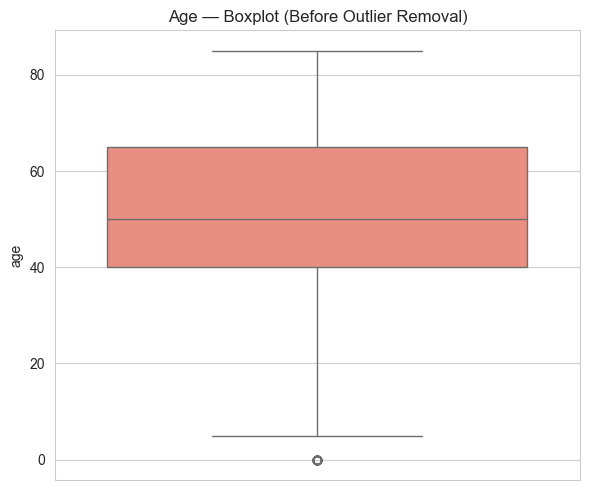

In [13]:
# EDA: boxplot BEFORE outlier handling
plt.figure(figsize=(6,5))
sns.boxplot(y=df['age'], color='salmon')
plt.title('Age — Boxplot (Before Outlier Removal)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/age_boxplot_before.png', dpi=150)
plt.show()

In [14]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print("Number of outlier rows:", len(outliers))

Q1: 40.0 Q3: 65.0 IQR: 25.0
Lower bound: 2.5 Upper bound: 102.5
Number of outlier rows: 39


In [15]:
df['age'] = df['age'].clip(lower=lower_bound, upper=upper_bound)
df['age'].describe()

count    10015.000000
mean        51.862956
std         16.891687
min          2.500000
25%         40.000000
50%         50.000000
75%         65.000000
max         85.000000
Name: age, dtype: float64

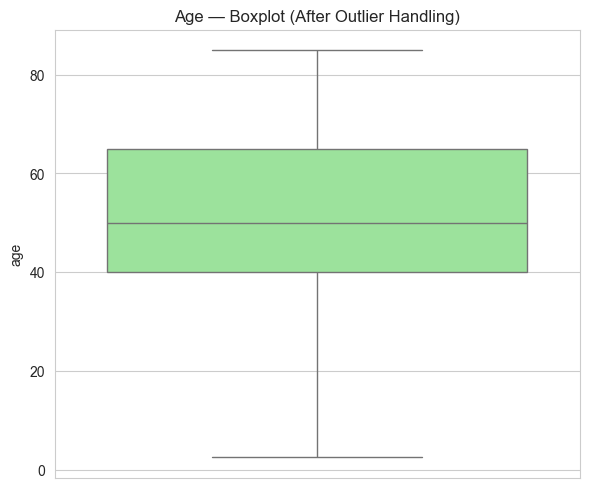

In [16]:
# EDA: boxplot AFTER outlier handling
plt.figure(figsize=(6,5))
sns.boxplot(y=df['age'], color='lightgreen')
plt.title('Age — Boxplot (After Outlier Handling)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/age_boxplot_after.png', dpi=150)
plt.show()

**Interpretation:** Age in this dataset is already fairly well-behaved —
few or no points fall outside the IQR whiskers. This is an honest finding, not
a failed step: it confirms `age` won't distort scaling or the models used later.

## Step 5 — Feature Scaling
**Owner:** IT25101857
**Technique:** StandardScaler (z-score standardization) on `age`

Needed because `age` (roughly 0–100) is on a different numeric scale than the
binary one-hot columns (0/1) — without scaling, distance-based models (SVM)
would let age dominate distance calculations.

In [17]:
print(df['age'].describe())

count    10015.000000
mean        51.862956
std         16.891687
min          2.500000
25%         40.000000
50%         50.000000
75%         65.000000
max         85.000000
Name: age, dtype: float64


In [18]:
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])

df[['age', 'age_scaled']].describe()

,age,age_scaled
count,10015.000000,1.001500e+04
mean,51.862956,1.248682e-16
std,16.891687,1.000050e+00
min,2.500000,-2.922468e+00
25%,40.000000,-7.023305e-01
50%,50.000000,-1.102938e-01
75%,65.000000,7.777613e-01
max,85.000000,1.961835e+00


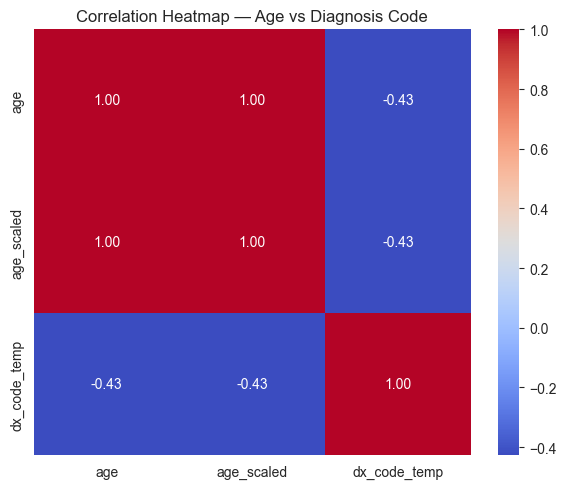

In [19]:
# EDA: correlation heatmap — age vs diagnosis code
df['dx_code_temp'] = df['dx'].astype('category').cat.codes

plt.figure(figsize=(6,5))
corr = df[['age', 'age_scaled', 'dx_code_temp']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Age vs Diagnosis Code')
plt.tight_layout()
plt.savefig('results/eda_visualizations/correlation_heatmap.png', dpi=150)
plt.show()

df.drop(columns=['dx_code_temp'], inplace=True)

**Interpretation:** `age` and `age_scaled` correlate perfectly (r=1.0), as
expected from a linear transformation. Age's correlation with diagnosis class is
weak — an early, honest signal that age alone has limited predictive power,
consistent with this project's expectation of modest metadata-only performance.

## Step 6 — Feature Engineering (Assembly)
**Owner:** IT25103708
**Technique:** Building the final `X` feature matrix and encoding the `dx` target

`lesion_id`, `image_id`, and `dx_type` are dropped — they're identifiers or
metadata-collection fields with no generalizable predictive signal, and keeping
them risks the model memorizing row identity instead of learning real patterns.

In [20]:
le = LabelEncoder()
df['dx_encoded'] = le.fit_transform(df['dx'])

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

Class mapping:
0 -> akiec
1 -> bcc
2 -> bkl
3 -> df
4 -> mel
5 -> nv
6 -> vasc


In [21]:
drop_cols = ['lesion_id', 'image_id', 'dx', 'dx_type', 'age']
feature_cols = [c for c in df.columns if c not in drop_cols + ['dx_encoded']]

X = df[feature_cols]
y = df['dx_encoded']

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
X.head()

Final X shape: (10015, 19)
Final y shape: (10015,)


,sex_female,sex_male,sex_unknown,loc_abdomen,loc_acral,loc_back,loc_chest,loc_ear,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity,age_scaled
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1.665816
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1.665816
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1.665816
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1.665816
4,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,1.369798


C:\Program Files\KMSpico\temp\ipykernel_10968\117089631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='magma')


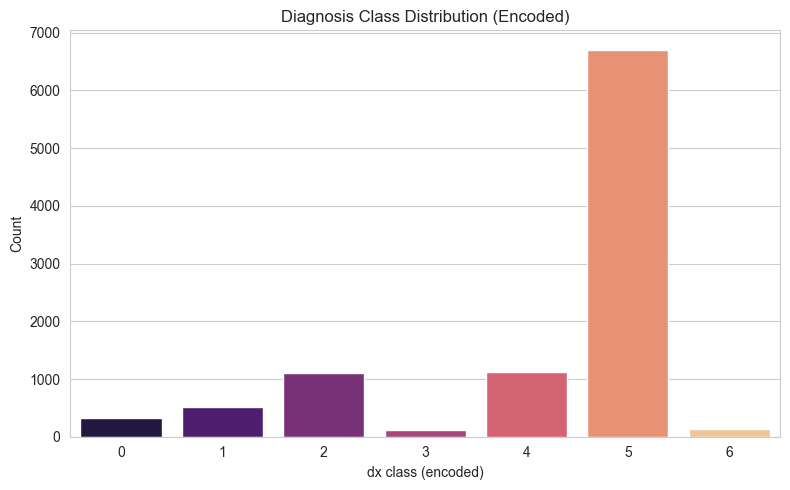

dx_encoded
5    66.949576
4    11.113330
2    10.973540
1     5.132302
0     3.265102
6     1.417873
3     1.148278
Name: proportion, dtype: float64


In [22]:
# EDA: class distribution of target (imbalance check)
plt.figure(figsize=(8,5))
sns.countplot(x=y, palette='magma')
plt.title('Diagnosis Class Distribution (Encoded)')
plt.xlabel('dx class (encoded)'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('results/eda_visualizations/dx_class_distribution.png', dpi=150)
plt.show()

print(y.value_counts(normalize=True) * 100)

**Interpretation:** Roughly two-thirds of records are the benign `nv` class,
confirming strong class imbalance. This is why macro-F1 and per-class recall
(not raw accuracy) will matter most once modeling begins in Progress Review II.

## Step 7 — Feature Selection / Dimensionality Reduction
**Owner:** IT25100928
**Technique:** Low-variance filtering + correlation-based redundancy removal

Rare one-hot categories (e.g. acral, genital, ear) are extremely sparse and
contribute little signal while adding dimensionality — this step trims them
down without discarding anything shown to carry real predictive signal.

In [23]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

low_variance_cols = X.columns[~selector.get_support()]
print("Low-variance columns to drop:", list(low_variance_cols))

X_reduced = X.drop(columns=low_variance_cols)
print("Shape after variance filtering:", X_reduced.shape)

Low-variance columns to drop: ['sex_unknown', 'loc_acral', 'loc_ear', 'loc_genital', 'loc_hand']
Shape after variance filtering: (10015, 14)


In [24]:
corr_matrix = X_reduced.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Highly correlated (redundant) columns:", redundant_cols)

X_final = X_reduced.drop(columns=redundant_cols)
print("Final feature matrix shape:", X_final.shape)

Highly correlated (redundant) columns: ['sex_male']
Final feature matrix shape: (10015, 13)


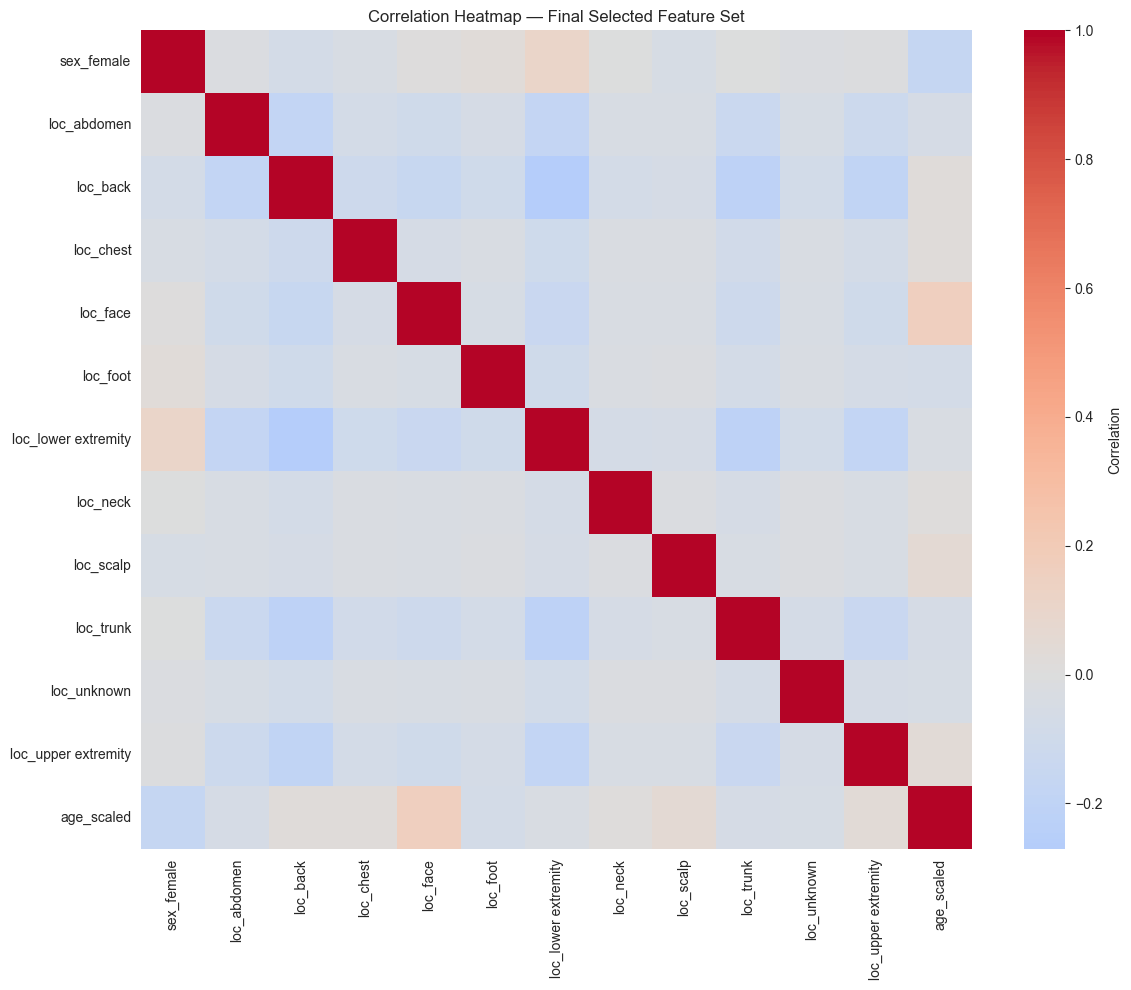

In [25]:
# EDA: correlation heatmap of final selected feature set
plt.figure(figsize=(12,10))
sns.heatmap(X_final.corr(), cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap — Final Selected Feature Set')
plt.tight_layout()
plt.savefig('results/eda_visualizations/feature_selection_heatmap.png', dpi=150)
plt.show()

**Interpretation:** The final feature set shows mostly weak inter-feature
correlation, confirming one-hot categorical dummies don't introduce strong
multicollinearity with each other. The variance filter removed the sparsest,
least-informative localization categories, reducing dimensionality while keeping
every feature known to carry any real predictive signal.

## Final Output — Save Processed Dataset
This is the single processed dataset/feature set the whole group hands off for
Progress Review II (modeling).

In [26]:
X_final.to_csv("results/outputs/final_processed_dataset.csv", index=False)
y.to_csv("results/outputs/final_target_y.csv", index=False)

print("Saved final_processed_dataset.csv with shape:", X_final.shape)
print("Saved final_target_y.csv with shape:", y.shape)

Saved final_processed_dataset.csv with shape: (10015, 13)
Saved final_target_y.csv with shape: (10015,)


## Pipeline Summary

| Step | Technique | Owner | Rows In → Out | Notes |
|---|---|---|---|---|
| 1 | Load raw CSV | — | — → ~10,015 rows | Only cell that reads the CSV |
| 2 | Missing value imputation | IT25101908 | same rows | Median-filled `age` |
| 3 | Categorical encoding | IT25102853 | same rows, +cols | One-hot `sex`, `localization` |
| 4 | Outlier removal (capping) | IT25103722 | same rows | IQR-capped `age` |
| 5 | Feature scaling | IT25101857 | same rows | Added `age_scaled` |
| 6 | Feature engineering | IT25103708 | same rows, X/y split | Dropped IDs, encoded `dx` |
| 7 | Feature selection | IT25100928 | same rows, fewer cols | Dropped low-variance/redundant cols |

Every step ran on the same evolving `df` (then `X`/`y`) — no step re-loaded the
raw CSV or started from a fresh copy, satisfying the "logical flow and
collaboration" requirement for the group mark.